<a href="https://colab.research.google.com/github/larissavaladao/time_series_curuai/blob/main/5.%20parameters_by_period/7.land_cover_time_series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importar pacotes

In [1]:
import geopandas as gpd
import pandas as pd
import math
import ee
import geemap
import json

In [2]:
ee.Authenticate()
ee.Initialize(project='ee-curuai2')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# mapbiomas curuai

In [14]:
import pandas as pd
df_classes_area = pd.read_csv('/content/drive/MyDrive/MAPBIOMAS-EXPORT-curuai/mapbiomas-brazil-collection-90-area.csv').drop(columns =['.geo','system:index'])

In [15]:
df_classes_area['year'] = df_classes_area['band'].apply(lambda name: int(name[-4:]))
df_classes_area

,area_km2,band,class,class_name,year
0,1175.695116,classification_1990,3,Forest Formation,1990
1,0.490409,classification_1990,4,Savanna Formation,1990
2,478.590515,classification_1990,6,Áreas Naturales Inundables - Leñosas (Bosque I...,1990
3,556.740850,classification_1990,11,Wetland,1990
4,16.369306,classification_1990,12,"Grassland (Pastizal, Formación Herbácea)",1990
...,...,...,...,...,...
322,254.774877,classification_2023,15,Pasture,2023
323,10.282167,classification_2023,24,Urban Infrastructure,2023
324,9.586696,classification_2023,25,Other Non Vegetated Area,2023
325,1407.783843,classification_2023,33,"River, Lake and Ocean",2023


In [17]:
df_classes_area['class_name'].unique()

array(['Forest Formation', 'Savanna Formation',
       'Áreas Naturales Inundables - Leñosas (Bosque Inundable)',
       'Wetland', 'Grassland (Pastizal, Formación Herbácea)', 'Pasture',
       'Urban Infrastructure', 'Other Non Vegetated Area',
       'River, Lake and Ocean', 'Mosaic of Crops'], dtype=object)

In [18]:
dados_non_nat = df_classes_area.loc[df_classes_area['class_name'].isin(['Pasture',
       'Urban Infrastructure', 'Other Non Vegetated Area','Mosaic of Crops','River, Lake and Ocean'])].copy()
dados_non_nat = dados_non_nat.groupby(by=['year']).sum()
dados_non_nat['class_name'] = 'Non-natural'
dados_non_nat

,area_km2,band,class,class_name
year,,,,
1990,1574.692252,classification_1990classification_1990classifi...,97,Non-natural
1991,1604.562110,classification_1991classification_1991classifi...,97,Non-natural
1992,1383.306299,classification_1992classification_1992classifi...,97,Non-natural
1993,1759.052779,classification_1993classification_1993classifi...,97,Non-natural
1994,1700.392586,classification_1994classification_1994classifi...,97,Non-natural
1995,1612.261339,classification_1995classification_1995classifi...,97,Non-natural
1996,1685.538895,classification_1996classification_1996classifi...,97,Non-natural
1997,1712.406462,classification_1997classification_1997classifi...,97,Non-natural
1998,1578.773048,classification_1998classification_1998classifi...,97,Non-natural


In [19]:
dados_nat = df_classes_area.loc[~df_classes_area['class_name'].isin(['Pasture',
       'Urban Infrastructure', 'Other Non Vegetated Area','Mosaic of Crops','River, Lake and Ocean'])].copy()
dados_nat = dados_nat.groupby(by=['year']).sum()
dados_nat['class_name'] = 'Natural'
dados_nat

,area_km2,band,class,class_name
year,,,,
1990,2227.886196,classification_1990classification_1990classifi...,36,Natural
1991,2198.016338,classification_1991classification_1991classifi...,36,Natural
1992,2419.272149,classification_1992classification_1992classifi...,36,Natural
1993,2043.525669,classification_1993classification_1993classifi...,36,Natural
1994,2102.185862,classification_1994classification_1994classifi...,36,Natural
1995,2190.317109,classification_1995classification_1995classifi...,36,Natural
1996,2117.039553,classification_1996classification_1996classifi...,36,Natural
1997,2090.171986,classification_1997classification_1997classifi...,36,Natural
1998,2223.805400,classification_1998classification_1998classifi...,36,Natural


In [20]:
dados = pd.concat([dados_nat,dados_non_nat])
dados

,area_km2,band,class,class_name
year,,,,
1990,2227.886196,classification_1990classification_1990classifi...,36,Natural
1991,2198.016338,classification_1991classification_1991classifi...,36,Natural
1992,2419.272149,classification_1992classification_1992classifi...,36,Natural
1993,2043.525669,classification_1993classification_1993classifi...,36,Natural
1994,2102.185862,classification_1994classification_1994classifi...,36,Natural
...,...,...,...,...
2019,1797.842356,classification_2019classification_2019classifi...,138,Non-natural
2020,1720.083041,classification_2020classification_2020classifi...,138,Non-natural
2021,1787.092617,classification_2021classification_2021classifi...,138,Non-natural


In [21]:
dados.to_csv('/content/drive/MyDrive/CURUAI_PROCESS/lulc_curuai.csv')

<Axes: xlabel='year', ylabel='area_km2'>

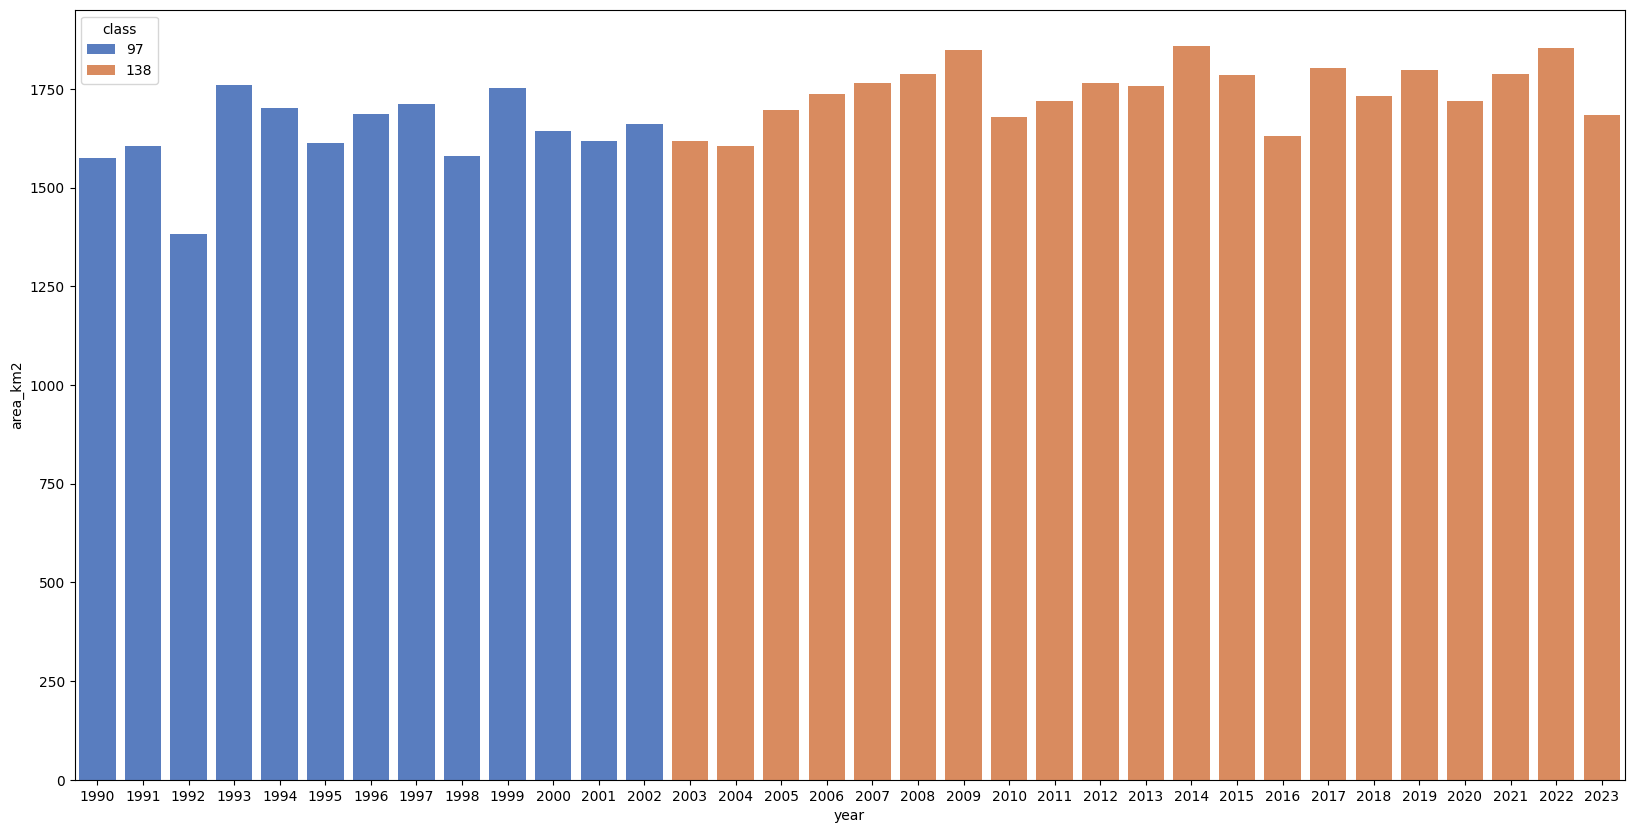

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt



# Initialize the matplotlib figure
f, ax = plt.subplots(figsize=(20, 10))

sns.barplot(data=dados_non_nat,x='year',y='area_km2',hue='class',palette="muted")

# mapbiomas bacia nivel 2

In [23]:
import pandas as pd
df_classes_area = pd.read_csv('/content/drive/MyDrive/MAPBIOMAS-EXPORT-curuai/mapbiomas-brazil-collection-90-area-n2.csv').drop(columns =['.geo','system:index'])

In [24]:
df_classes_area['year'] = df_classes_area['band'].apply(lambda name: int(name[-4:]))
df_classes_area

,area_km2,band,class,class_name,year
0,0.028574,classification_1990,0,Non Observed,1990
1,312859.141341,classification_1990,3,Forest Formation,1990
2,540.891614,classification_1990,4,Savanna Formation,1990
3,19388.797956,classification_1990,6,Áreas Naturales Inundables - Leñosas (Bosque I...,1990
4,0.006254,classification_1990,9,Forest Plantation,1990
...,...,...,...,...,...
499,269.130859,classification_2023,29,Rocky outcrop,2023
500,283.118351,classification_2023,30,Mining,2023
501,19494.180916,classification_2023,33,"River, Lake and Ocean",2023
502,3.449346,classification_2023,39,Soy Beans,2023


In [25]:
df_classes_area['class_name'].unique()

array(['Non Observed', 'Forest Formation', 'Savanna Formation',
       'Áreas Naturales Inundables - Leñosas (Bosque Inundable)',
       'Forest Plantation', 'Wetland',
       'Grassland (Pastizal, Formación Herbácea)', 'Pasture',
       'Urban Infrastructure', 'Other Non Vegetated Area',
       'Rocky outcrop', 'Mining', 'River, Lake and Ocean',
       'Mosaic of Crops', 'Sugar Cane', 'Soy Beans'], dtype=object)

In [26]:
classes = ['Pasture',
       'Urban Infrastructure', 'Other Non Vegetated Area',
       'Rocky outcrop', 'Mining','River, Lake and Ocean',
       'Mosaic of Crops', 'Sugar Cane', 'Soy Beans']
dados_non_nat = df_classes_area.loc[df_classes_area['class_name'].isin(classes)].copy()
dados_non_nat = dados_non_nat.groupby(by=['year']).sum()
dados_non_nat['class_name'] = 'Non-natural'
dados_non_nat

,area_km2,band,class,class_name
year,,,,
1990,21347.792263,classification_1990classification_1990classifi...,197,Non-natural
1991,21911.698781,classification_1991classification_1991classifi...,197,Non-natural
1992,21117.923121,classification_1992classification_1992classifi...,197,Non-natural
1993,22516.000795,classification_1993classification_1993classifi...,197,Non-natural
1994,23115.264316,classification_1994classification_1994classifi...,197,Non-natural
1995,22887.215254,classification_1995classification_1995classifi...,197,Non-natural
1996,23719.076518,classification_1996classification_1996classifi...,197,Non-natural
1997,23307.621953,classification_1997classification_1997classifi...,156,Non-natural
1998,22252.476182,classification_1998classification_1998classifi...,197,Non-natural


In [28]:
dados_nat = df_classes_area.loc[(~df_classes_area['class_name'].isin(classes)) & (df_classes_area['class_name'] != 'Non Observed')].copy()
dados_nat = dados_nat.groupby(by=['year']).sum()
dados_nat['class_name'] = 'Natural'
dados_nat

,area_km2,band,class,class_name
year,,,,
1990,345217.080145,classification_1990classification_1990classifi...,45,Natural
1991,344653.178984,classification_1991classification_1991classifi...,45,Natural
1992,345446.945719,classification_1992classification_1992classifi...,45,Natural
1993,344048.867143,classification_1993classification_1993classifi...,45,Natural
1994,343449.603626,classification_1994classification_1994classifi...,45,Natural
1995,343677.650905,classification_1995classification_1995classifi...,45,Natural
1996,342845.793210,classification_1996classification_1996classifi...,45,Natural
1997,343257.240640,classification_1997classification_1997classifi...,45,Natural
1998,344312.391761,classification_1998classification_1998classifi...,45,Natural


In [29]:
dados = pd.concat([dados_nat,dados_non_nat])
dados

,area_km2,band,class,class_name
year,,,,
1990,345217.080145,classification_1990classification_1990classifi...,45,Natural
1991,344653.178984,classification_1991classification_1991classifi...,45,Natural
1992,345446.945719,classification_1992classification_1992classifi...,45,Natural
1993,344048.867143,classification_1993classification_1993classifi...,45,Natural
1994,343449.603626,classification_1994classification_1994classifi...,45,Natural
...,...,...,...,...
2019,26338.284766,classification_2019classification_2019classifi...,256,Non-natural
2020,25870.311102,classification_2020classification_2020classifi...,256,Non-natural
2021,26992.318373,classification_2021classification_2021classifi...,256,Non-natural


In [30]:
dados.to_csv('/content/drive/MyDrive/CURUAI_PROCESS/lulc_curuaiN2.csv')

<Axes: xlabel='year', ylabel='area_km2'>

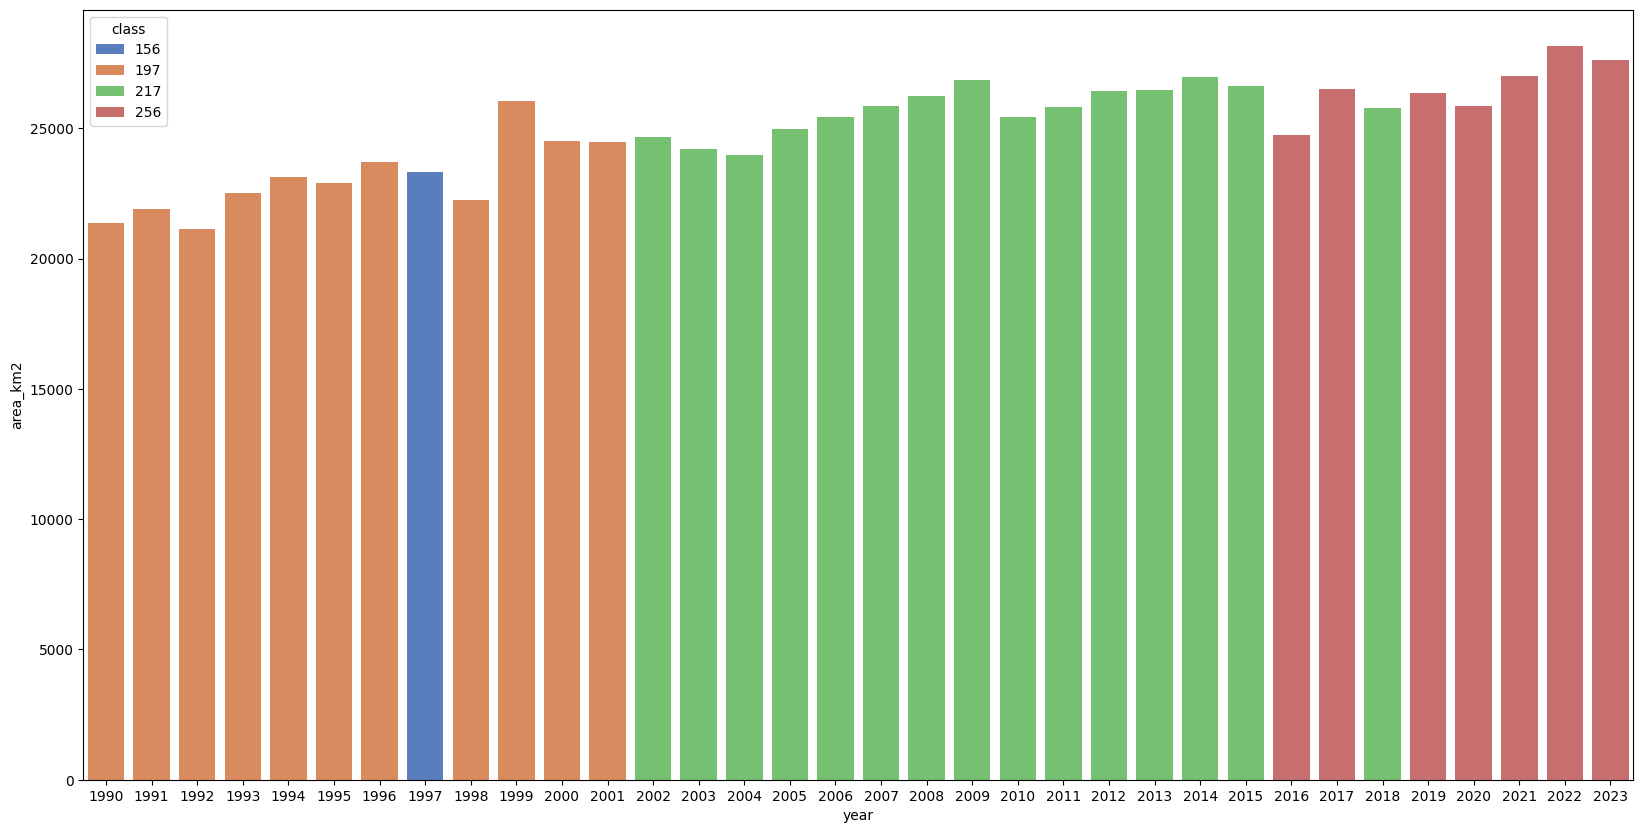

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt



# Initialize the matplotlib figure
f, ax = plt.subplots(figsize=(20, 10))

sns.barplot(data=dados_non_nat,x='year',y='area_km2',hue='class',palette="muted")